In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import data
# data before 2025
old_data = pd.read_csv("original_data/dati-centraline-bologna-storico.csv", delimiter=";")
# 2025 data
new_data = pd.read_csv(
    "original_data/centraline-qualita-aria.csv", delimiter=";"
)

# process the 2 CSV to make them compatible
new_data = pd.read_csv("original_data/centraline-qualita-aria.csv", delimiter=";")
new_data = new_data.rename(
    columns={"reftime": "time", "agente_atm": "gas", "stazione": "station"}
)
new_data = new_data.drop(columns=["_id"])
new_data["gas"] = new_data["gas"].str.upper()
station_names_map = {
    "GIARDINI MARGHERITA, BOLOGNA VIALE BOTTONELLI": "GIARDINI MARGHERITA",
    "VIA CHIARINI, BOLOGNA VIA CHIARINI": "VIA CHIARINI",
    "PORTA SAN FELICE, BOLOGNA PIAZZA DI PORTA SAN FELICE": "PORTA SAN FELICE",
}
new_data["station"] = new_data["station"].map(station_names_map)

old_data = old_data.rename(
    columns={
        "DATA_INIZIO": "time",
        "AGENTE": "gas",
        "COD_STAZ": "station",
        "VALORE": "value",
    }
)
old_data = old_data.drop(columns=["DATA_FINE", "UM"])

# check if the gases are the same
print(set(old_data["gas"].unique()) == set(new_data["gas"].unique()))

True


In [2]:
# concat the 2 CSV
data = pd.concat([old_data, new_data], axis=0, ignore_index=True)

# remove VIA CHIARINI station data
data = data[data["station"] != "VIA CHIARINI"]

# convert data to UTC format Eg: 2016-12-30 23:01:00+00:00
data["time"] = pd.to_datetime(data["time"], utc=True)
data["time"] = pd.to_datetime(data["time"], utc=True)

# remove data before 2019
data = data[data["time"] >= "2019-01-01"]

# order from most recent
data = data.sort_values(by="time", ascending=False)

# create a dictionary where each key is a gas that has as value the dataframe with the gas data
gases = data["gas"].unique()
gases_dict = {gas: data[data["gas"] == gas].copy() for gas in gases}

# not interesting for human health
del gases_dict["NOX (OSSIDI DI AZOTO)"]
del gases_dict["NO (MONOSSIDO DI AZOTO)"]

# which stations measures which gases
for gas, gas_df in gases_dict.items():
    stations = gas_df["station"].unique()
    print(f"{gas}: {', '.join(stations)}")

PM10: GIARDINI MARGHERITA, PORTA SAN FELICE
O3 (OZONO): GIARDINI MARGHERITA
CO (MONOSSIDO DI CARBONIO): PORTA SAN FELICE
NO2 (BIOSSIDO DI AZOTO): PORTA SAN FELICE, GIARDINI MARGHERITA
PM2.5: GIARDINI MARGHERITA, PORTA SAN FELICE
C6H6 (BENZENE): PORTA SAN FELICE


In [3]:
# for each gas, compute year-&-station means of VALORE
year_station_means = {}

for gas, df_gas in gases_dict.items():
    # extract year and day
    df_gas["year"] = df_gas["time"].dt.year
    df_gas["day"] = df_gas["time"].dt.date

    # compute daily means per station
    day_mean = df_gas.groupby(["day", "station", "year"], as_index=False)[
        "value"
    ].mean()

    # now compute the mean of those daily means **by** year AND station
    year_mean = (
        day_mean.groupby(["year", "station"], as_index=False)["value"]
        .mean()
        .rename(columns={"value": "yearly_mean"})
    )

    # store result
    year_station_means[gas] = year_mean

# Example
year_station_means["O3 (OZONO)"]

,year,station,yearly_mean
0,2019,GIARDINI MARGHERITA,49.865309
1,2020,GIARDINI MARGHERITA,47.033161
2,2021,GIARDINI MARGHERITA,46.641242
3,2022,GIARDINI MARGHERITA,51.190006
4,2023,GIARDINI MARGHERITA,52.364133
5,2024,GIARDINI MARGHERITA,46.974363
6,2025,GIARDINI MARGHERITA,49.180697


In [13]:
# remove via chiarini because it is not relevant for zone 30 and not enough gases are measured there
for gas, gas_df in year_station_means.items():
    year_station_means[gas] = gas_df[gas_df["station"] != "VIA CHIARINI"]

# eg
year_station_means["NO2 (BIOSSIDO DI AZOTO)"]

,year,station,yearly_mean
0,2019,GIARDINI MARGHERITA,20.489283
1,2019,PORTA SAN FELICE,46.449569
3,2020,GIARDINI MARGHERITA,17.003752
4,2020,PORTA SAN FELICE,38.532610
6,2021,GIARDINI MARGHERITA,16.510233
7,2021,PORTA SAN FELICE,43.320746
9,2022,GIARDINI MARGHERITA,18.390174
10,2022,PORTA SAN FELICE,38.979245
12,2023,GIARDINI MARGHERITA,15.649784
13,2023,PORTA SAN FELICE,42.781264


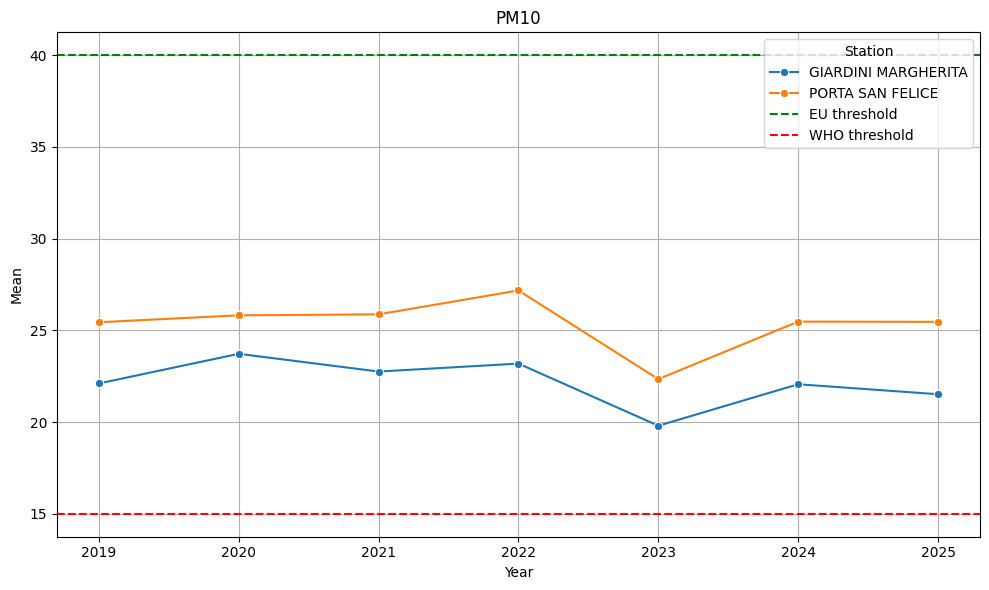

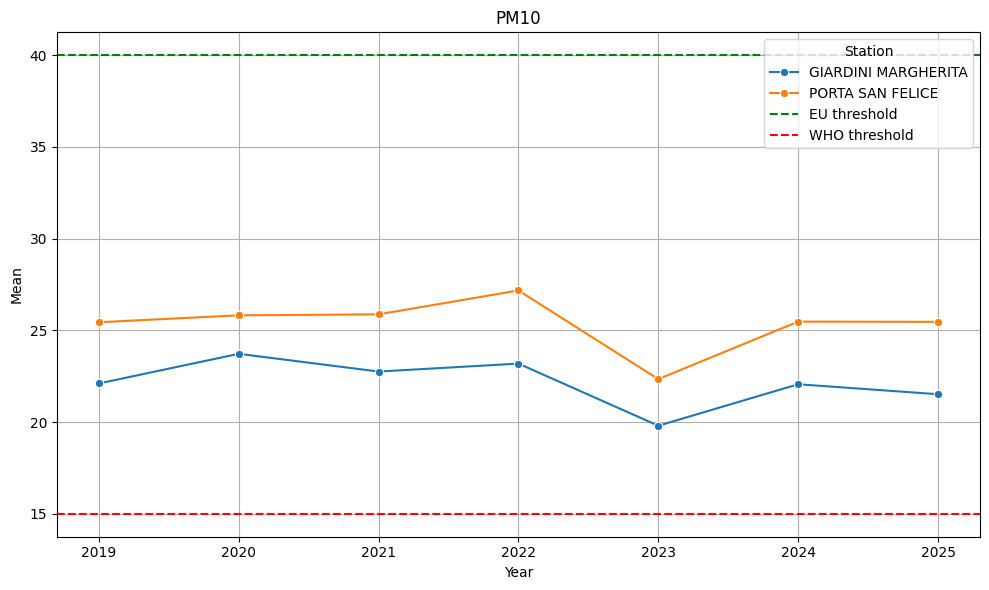

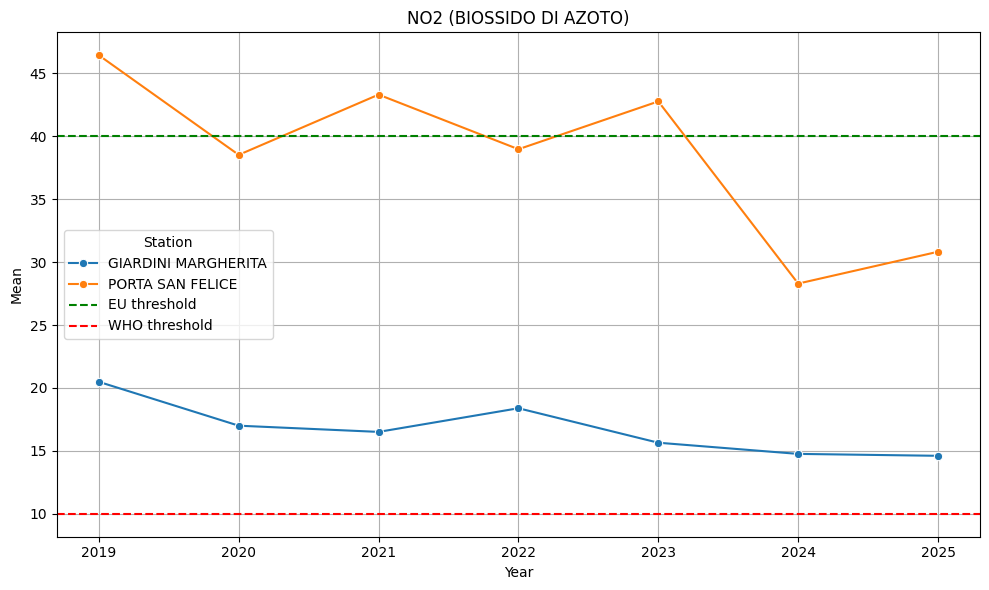

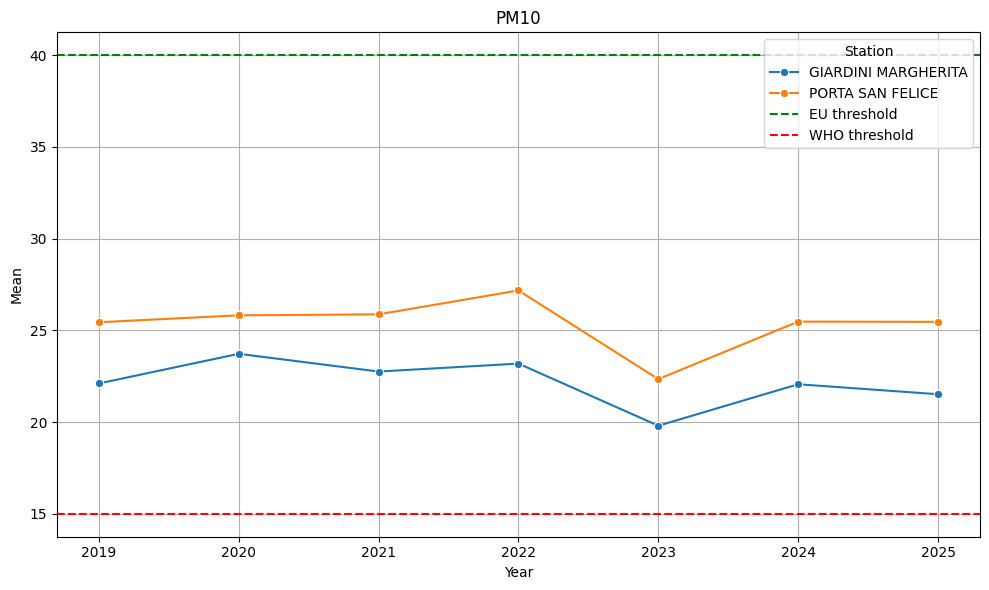

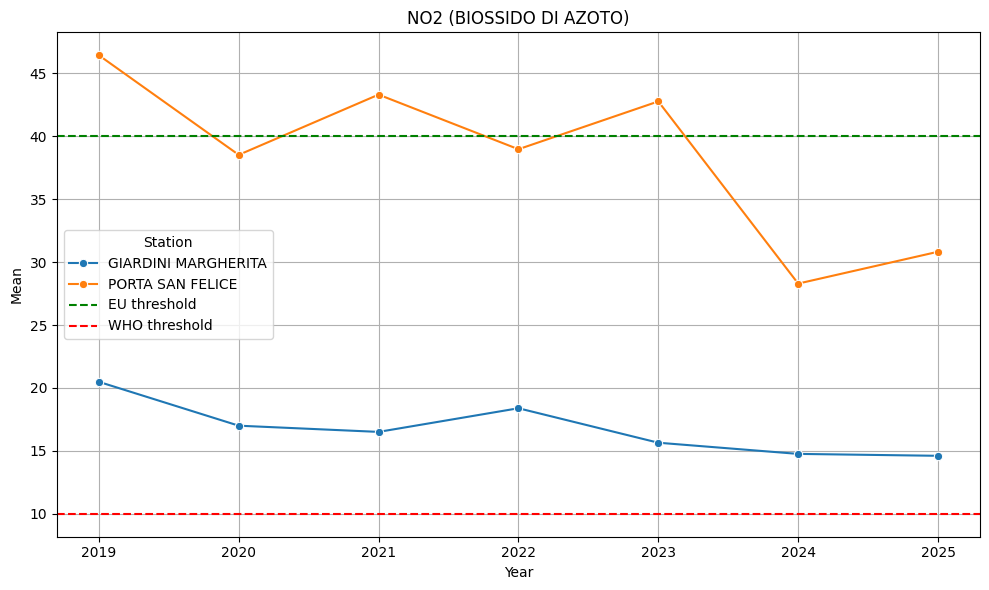

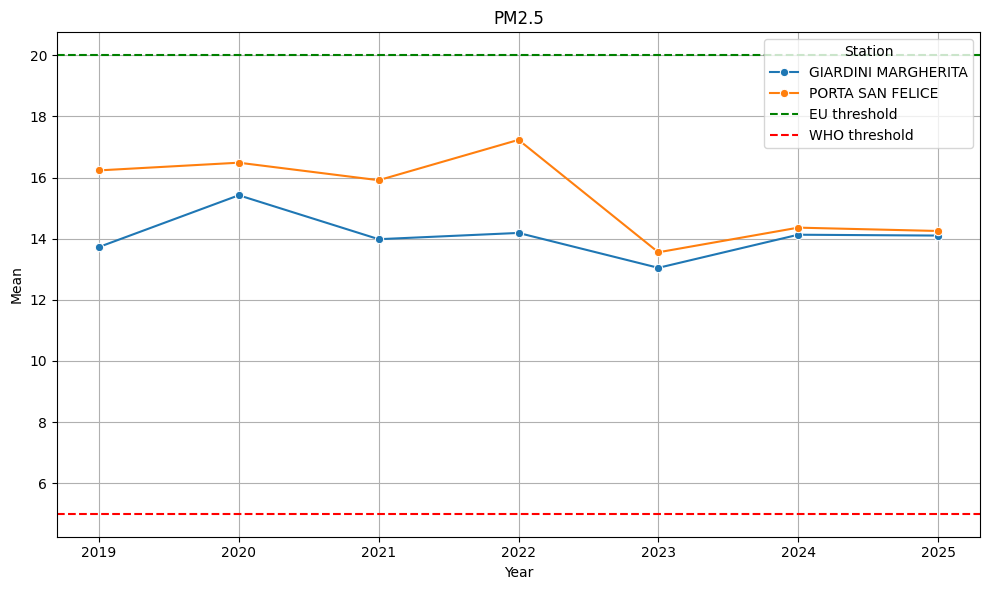

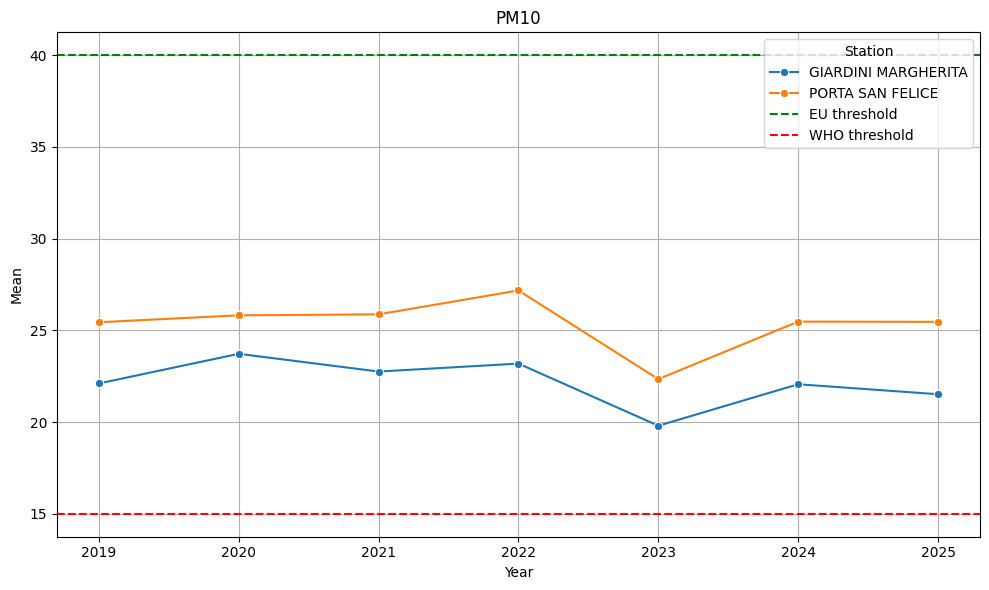

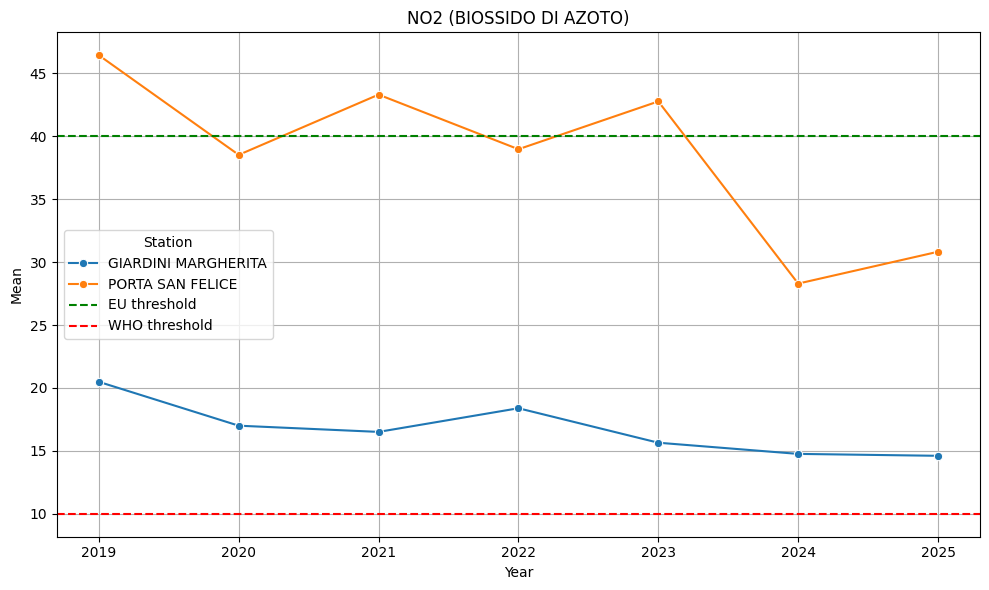

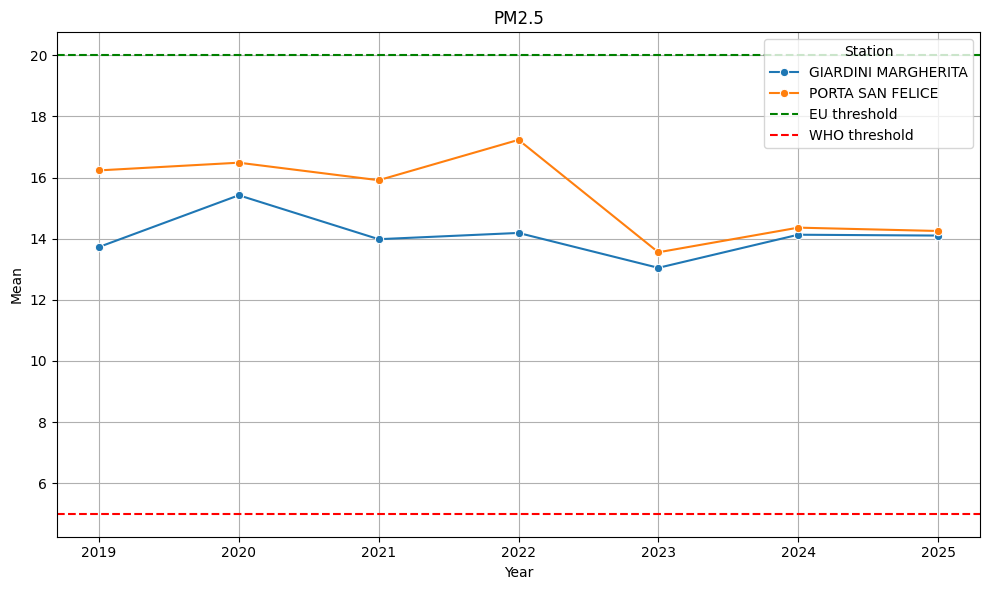

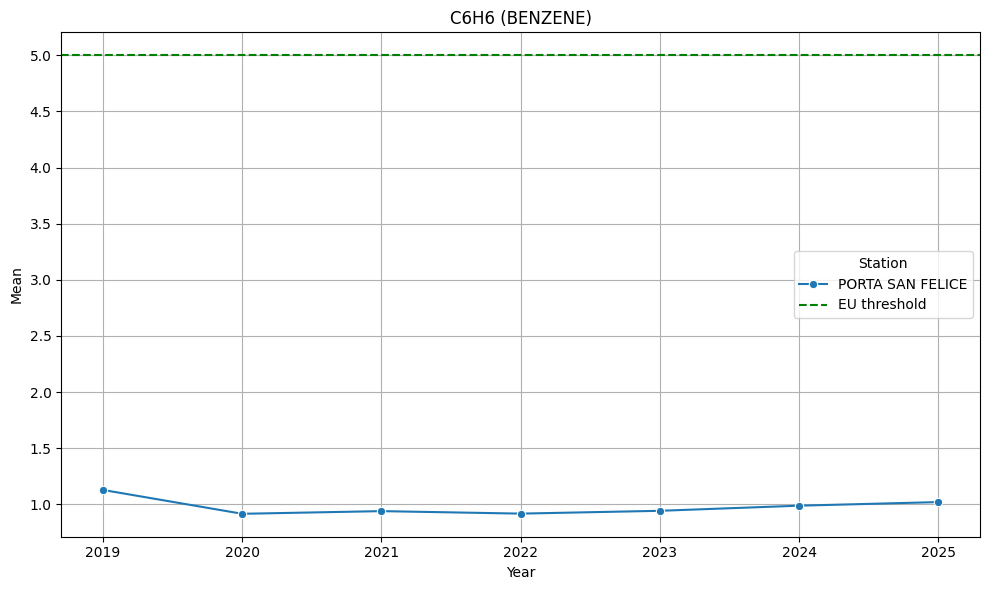

In [4]:
# plotting time
thresholds = {
    "C6H6 (BENZENE)": {"EU": 5},
    # "O3 (OZONO)": {"EU":}, different way of calculating the threhsold - see later
    # "CO (MONOSSIDO DI CARBONIO)": {"EU":}, different way of calculating the threhsold - see later
    "NO2 (BIOSSIDO DI AZOTO)": {"WHO": 10, "EU": 40},
    "PM2.5": {"WHO": 5, "EU": 20},
    "PM10": {"WHO": 15, "EU": 40},
}

for gas, gas_df in year_station_means.items():

    if gas in thresholds:
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=gas_df, x="year", y="yearly_mean", marker="o", hue="station")

        # Add threshold line
        WHO_THRESHOLD = thresholds.get(gas).get("WHO")
        EU_THRESHOLD = thresholds.get(gas).get("EU")

        if EU_THRESHOLD:
            plt.axhline(
                y=EU_THRESHOLD,
                color="green",
                linestyle="--",
                linewidth=1.5,
                label="EU threshold",
            )

        if WHO_THRESHOLD:
            plt.axhline(
                y=WHO_THRESHOLD,
                color="red",
                linestyle="--",
                linewidth=1.5,
                label="WHO threshold",
            )

        # show every year
        years = sorted(list(gas_df["year"].unique()))
        plt.xticks(ticks=years)

        plt.title(f"{gas}")
        plt.xlabel("Year")
        plt.ylabel("Mean")
        plt.legend(title="Station")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

**OZONE 03**

/var/folders/pn/fjbkbl1119z07xq7zv89lw240000gn/T/ipykernel_1421/4141344662.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(  # treat each station separately


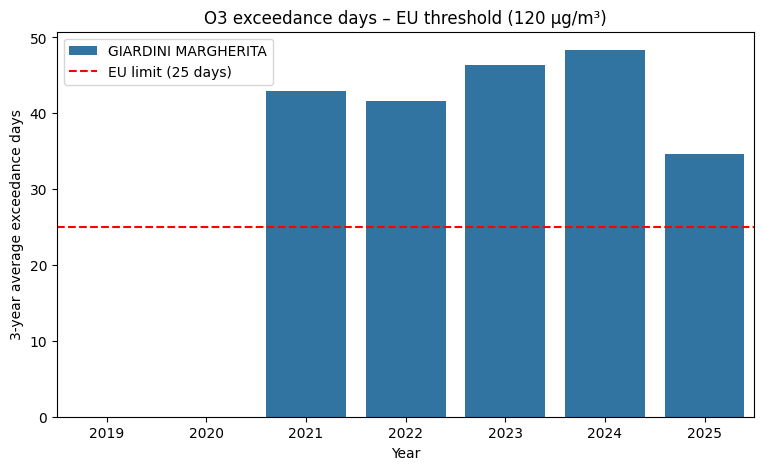

In [8]:
# OZONE
df_gas = gases_dict["O3 (OZONO)"].copy()

# ensure time is sorted
df_gas = df_gas.sort_values(by=["station", "time"])

# compute 8-hour rolling mean for each station
df_gas["rolling_8h_mean"] = (
    df_gas.groupby("station")["value"]
    .rolling(window=8, min_periods=6)  # allow at least 6 valid hours
    .mean()
    .reset_index(level=0, drop=True)
)

# get which of the 8 hours mean is the highest
df_gas["day"] = df_gas["time"].dt.date

daily_max_8h = (
    df_gas.groupby(["station", "day"], as_index=False)["rolling_8h_mean"]
    .max()
    .rename(columns={"rolling_8h_mean": "max_8h_mean"})
)

# count how many days per year exceed the EU target value (120)
daily_max_8h["year"] = pd.to_datetime(daily_max_8h["day"]).dt.year


# --- EU ---
exceedances_eu = (
    daily_max_8h[daily_max_8h["max_8h_mean"] > 120]
    .groupby(["station", "year"])
    .size()
    .reset_index(name="exceedance_days")
)

exceedances_eu["above_eu_target"] = exceedances_eu["exceedance_days"] > 25
exceedances_eu = exceedances_eu.sort_values(["station", "year"])

three_year_avg_eu = exceedances_eu.groupby(
    "station", group_keys=False
).apply(  # treat each station separately
    lambda g: g.sort_values("year").assign(
        three_year_avg_days=g["exceedance_days"].rolling(window=3, min_periods=3).mean()
    )
)
three_year_avg_eu["standard"] = "EU (120 µg/m³)"

# insert in the data 
year_station_means["O3 (OZONO)"] = {"eu": three_year_avg_eu, "who": None}

plt.figure(figsize=(9, 5))
sns.barplot(
    data=three_year_avg_eu,
    x="year",
    y="three_year_avg_days",
    hue="station",  
    errorbar=None,
)

plt.title("O3 exceedance days – EU threshold (120 µg/m³)")
plt.xlabel("Year")
plt.ylabel("3-year average exceedance days")
plt.axhline(25, color="red", linestyle="--", label="EU limit (25 days)")
plt.legend()
plt.show()

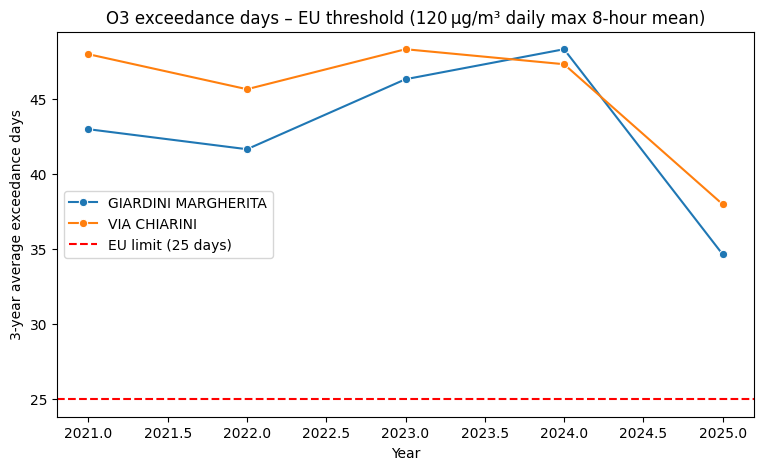

In [12]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=three_year_avg_eu,
    x="year",
    y="three_year_avg_days",
    hue="station",
    marker="o",
    errorbar=None,
)


plt.title("O3 exceedance days – EU threshold (120 µg/m³ daily max 8-hour mean)")
plt.xlabel("Year")
plt.ylabel("3-year average exceedance days")
plt.axhline(25, color="red", linestyle="--", label="EU limit (25 days)")
plt.legend()
plt.show()

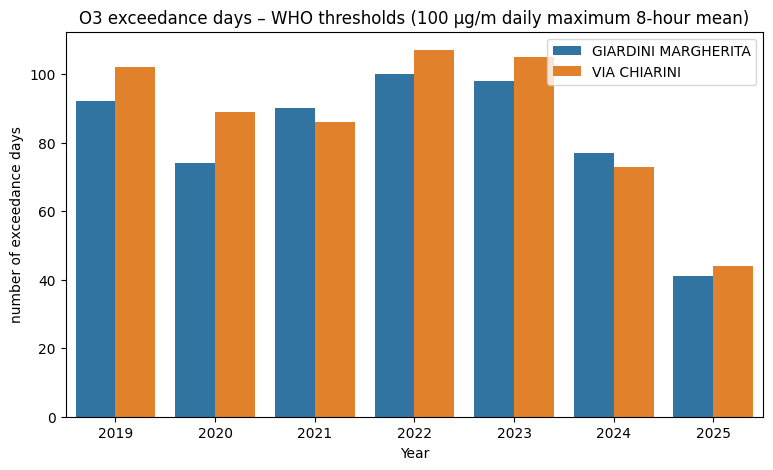

In [12]:
# --- WHO ---
exceedances_who = (
    daily_max_8h[daily_max_8h["max_8h_mean"] > 100]
    .groupby(["station", "year"])
    .size()
    .reset_index(name="exceedance_days")
)
exceedances_who = exceedances_who.sort_values(["station", "year"])

year_station_means["O3 (OZONO)"]["who"] = exceedances_who

plt.figure(figsize=(9, 5))
sns.barplot(
    data=exceedances_who,
    x="year",
    y="exceedance_days",
    hue="station",  
    errorbar=None,
)

plt.title("O3 exceedance days – WHO thresholds (100 µg/m daily maximum 8-hour mean)")
plt.xlabel("Year")
plt.ylabel("number of exceedance days")
plt.legend()
plt.show()

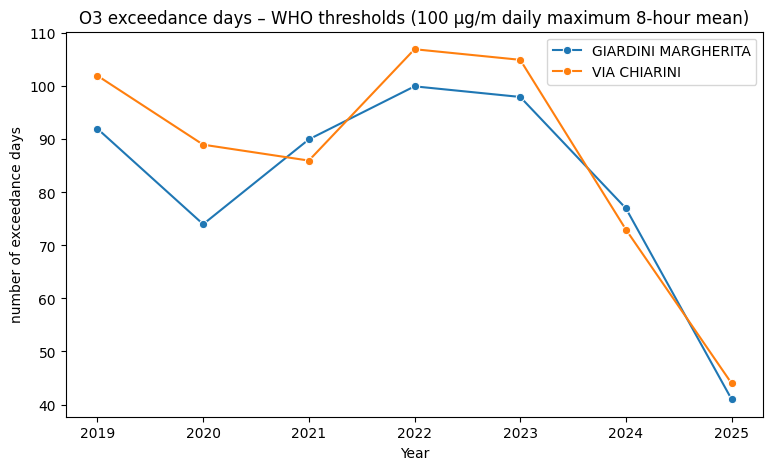

In [18]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=exceedances_who,
    x="year",
    y="exceedance_days",
    hue="station", 
      marker="o",
    errorbar=None,
)

plt.title("O3 exceedance days – WHO thresholds (100 µg/m daily maximum 8-hour mean)")
plt.xlabel("Year")
plt.ylabel("number of exceedance days")
plt.legend()
plt.show()

### CO

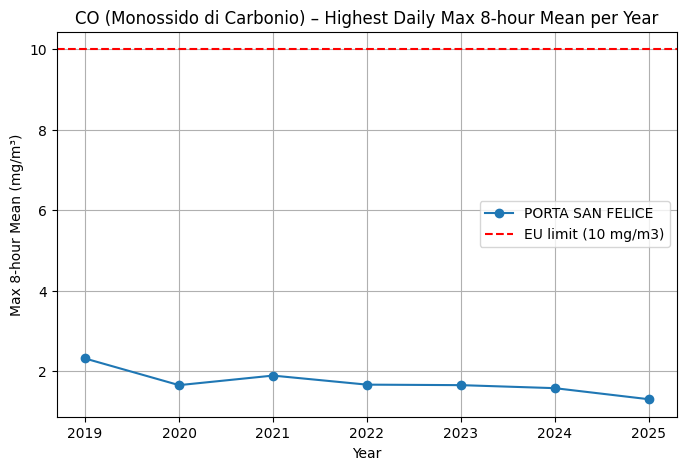

In [13]:
df_gas = gases_dict["CO (MONOSSIDO DI CARBONIO)"].copy()
df_gas = df_gas.sort_values(by=["station", "time"])

df_gas["rolling_8h_mean"] = (
    df_gas.groupby("station")["value"]
    .rolling(window=8, min_periods=6)
    .mean()
    .reset_index(level=0, drop=True)
)

# get which of the 8 hours mean is the highest
df_gas["day"] = df_gas["time"].dt.date

daily_max_8h = (
    df_gas.groupby(["station", "day"], as_index=False)["rolling_8h_mean"]
    .max()
    .rename(columns={"rolling_8h_mean": "max_8h_mean"})
)

daily_max_8h["year"] = pd.to_datetime(daily_max_8h["day"]).dt.year

yearly_max_8h = (
    daily_max_8h.groupby(["station", "year"], as_index=False)["max_8h_mean"]
    .max()
    .rename(columns={"max_8h_mean": "yearly_max_8h_mean"})
)

year_station_means["CO (MONOSSIDO DI CARBONIO)"] = yearly_max_8h

plt.figure(figsize=(8, 5))

for station, df_station in yearly_max_8h.groupby("station"):
    plt.plot(
        df_station["year"], df_station["yearly_max_8h_mean"], marker="o", label=station
    )

plt.title("CO (Monossido di Carbonio) – Highest Daily Max 8-hour Mean per Year")
plt.xlabel("Year")
plt.ylabel("Max 8-hour Mean (mg/m³)")
plt.axhline(10, color="red", linestyle="--", label="EU limit (10 mg/m3)")
plt.legend()
plt.grid(True)
plt.show()

CO (Monossido di Carbonio – Carbon Monoxide)
Directly emitted by cars, especially petrol and older vehicles. -> so it can be just the use of new vehicles

Save data to use in D3

In [24]:
import json
from datetime import date

# Convert all timestamps and dates to strings in each DataFrame
def convert_datetime_objects(x):
    if isinstance(x, pd.Timestamp):
        return x.isoformat()
    elif isinstance(x, date):
        return x.isoformat()
    else:
        return x

json_dict = {
    key: df.copy().map(convert_datetime_objects).to_dict(orient="records")
    for key, df in year_station_means.items()
}

# Save to JSON file
with open("gases.json", "w") as f:
    json.dump(json_dict, f, indent=2)  # indent=2 makes it more readable